# Configuración previa

## Importación de librerías

In [1]:
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
import seaborn

import joblib

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    Dense, Embedding, LSTM, GRU, SimpleRNN, Bidirectional, Flatten, Input, Dropout,
    Conv2D, MaxPooling2D, GlobalMaxPooling2D, GlobalAveragePooling2D, BatchNormalization,
    AveragePooling2D, SeparableConv2D
)

from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
import random

import tensorflow as tf

from collections import Counter

from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Replicabilidad

In [2]:
seed = 0
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

## GPU

In [3]:
if tf.config.list_physical_devices('GPU'):
    print("GPU is available")
else:
    print("GPU is not available")

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        tf.config.experimental.set_virtual_device_configuration(
            physical_devices[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=4096)]
        )
        print("GPU configured")
    except RuntimeError as e:
        print(e)

GPU is available
GPU configured


## Comprobación de estructura de las imágenes

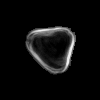

In [ ]:
sample = Image.open("data/Tipo_A_Kunzea/Kunzea_12.png")
sample

In [ ]:
np.max(np.array(sample)), np.array(sample).shape, np.array(sample)

(np.uint8(241),
 (100, 100),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

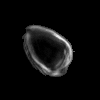

In [ ]:
sample = Image.open("data/Tipo_B_Lepto/Lepto_50.png")
sample

In [ ]:
np.max(np.array(sample)), np.array(sample).shape, np.array(sample)

(np.uint8(242),
 (100, 100),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

# Carga y preprocesamiento

## Carga

### Datos

In [ ]:
directory_A = './data/Tipo_A_Kunzea'
directory_B = './data/Tipo_B_Lepto'


files_A = os.listdir(directory_A)
files_B = os.listdir(directory_B)


if not (len(files_A) == len(files_B) == 1200):
    raise Exception("Error in files. Check the filespath.")


lists_A = []
lists_B = []

for index in range(1200):
    temp_A = Image.open(os.path.join(directory_A, files_A[index]))
    lists_A.append(np.array(temp_A) / 255)

    temp_B = Image.open(os.path.join(directory_B, files_B[index]))
    lists_B.append(np.array(temp_B) / 255)



images_A = np.array(lists_A).reshape(-1, 100, 100, 1)
images_B = np.array(lists_B).reshape(-1, 100, 100, 1)

images_A.shape, images_B.shape

((1200, 100, 100, 1), (1200, 100, 100, 1))

In [ ]:
data = np.concatenate((images_A, images_B))
labels = np.concatenate((np.full(1200, 'Tipo A - Kunzea'), np.full(1200, 'Tipo B - Lepto')))

data.shape

(2400, 100, 100, 1)

## Guardado opcional de datos

#### Exportar datos

In [ ]:
polem_data = {
    'data': data,
    'labels': labels,
}

joblib.dump(polem_data, './data/polem_data.joblib')

['./data/polem_data.joblib']

#### Leer datos exportados

In [5]:
polem_data = joblib.load('./data/polem_data.joblib')

data = polem_data['data']
labels = polem_data['labels']

## Preprocesamiento

### Codificación de etiquetas

In [6]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

### División de conjuntos

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(data, labels_encoded, test_size=0.30, stratify=labels_encoded, random_state=seed)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=seed)


X_train.shape, X_val.shape, X_test.shape

((1680, 100, 100, 1), (360, 100, 100, 1), (360, 100, 100, 1))

In [8]:
print(Counter(y_train).most_common())
print(Counter(y_val).most_common())
print(Counter(y_test).most_common())

[(np.int64(1), 840), (np.int64(0), 840)]
[(np.int64(0), 180), (np.int64(1), 180)]
[(np.int64(1), 180), (np.int64(0), 180)]


### Data Augmentation

In [9]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    fill_mode='reflect'
)

def generate_samples(X_train, y_train, datagen=datagen, n_samples=5):

    syntetic_samples = []

    for image in X_train:
        images_list = [datagen.random_transform(image) for _ in range(n_samples)]
        syntetic_samples.extend(images_list)

    data = np.concatenate((X_train, syntetic_samples))
    labels = np.concatenate((y_train, np.repeat(y_train, n_samples)))

    return data, labels


X_train_augmented, y_train_augmented = generate_samples(X_train, y_train)

X_train_augmented.shape, y_train_augmented.shape

((10080, 100, 100, 1), (10080,))

#### Pruebas individuales

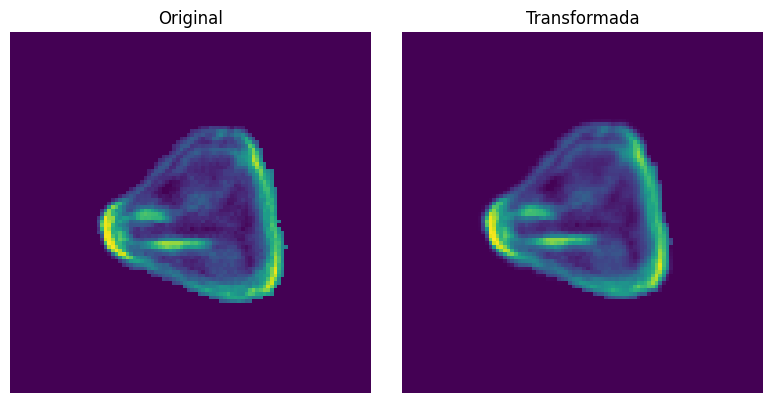

In [ ]:
original_image = X_train[0]

transformed_image = datagen.random_transform(original_image)

# Visualizar
plt.figure(figsize=(8, 4))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(original_image.squeeze())#, cmap='gray')
plt.title("Original")
plt.axis("off")

# Imagen transformada
plt.subplot(1, 2, 2)
plt.imshow(transformed_image.squeeze())#, cmap='gray')
plt.title("Transformada")
plt.axis("off")

plt.tight_layout()
plt.show()

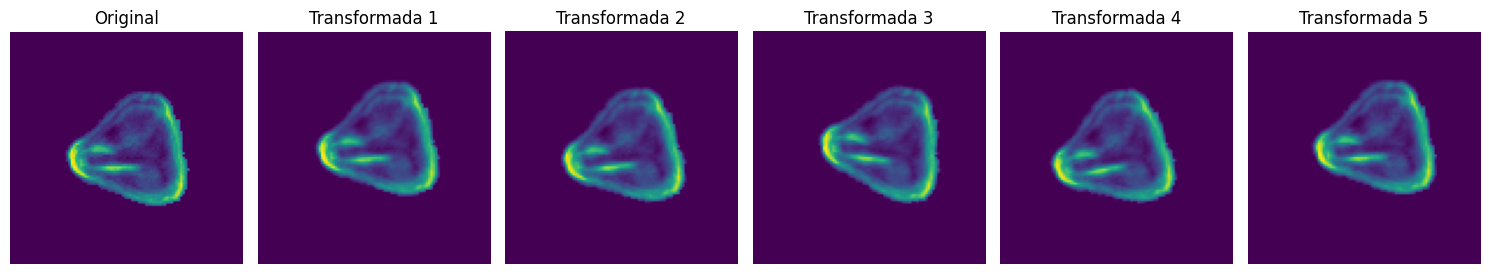

In [ ]:
original_image = X_train[0]

augmented_images = [datagen.random_transform(original_image) for _ in range(5)]

# Crear figura con 6 columnas (original + 5 transformaciones)
plt.figure(figsize=(15, 3))

# Mostrar original
plt.subplot(1, 6, 1)
plt.imshow(original_image.squeeze())
plt.title("Original")
plt.axis("off")

# Mostrar transformaciones
for i in range(5):
    plt.subplot(1, 6, i + 2)
    plt.imshow(augmented_images[i].squeeze())
    plt.title(f"Transformada {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Funciones

## Funciones de visualización

In [10]:
def plot_history(history):
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

In [11]:
def plot_confusion_matrix(test_labels, predictions):
    cm = confusion_matrix(test_labels, predictions)

    plt.figure(figsize=(5, 4))
    seaborn.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')

    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.title('Matriz de confusión')
    plt.ylabel('Etiqueta verdadera')
    plt.xlabel('Etiqueta predicha')
    plt.show()

## Funciones de evaluación

In [21]:
def training(model, train_data=X_train, train_labels=y_train, val_data=X_val, val_labels=y_val, epochs=150, batch_size=128):

    optimizer = Adam(learning_rate=0.0001)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['acc'])


    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=15,
            min_delta=0.005,
            restore_best_weights=True,
            mode='min',
            verbose=1
        )
    ]

    history = model.fit(
        train_data,
        np.array(train_labels),
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(val_data, val_labels),
        callbacks=callbacks,
        verbose=0
    )

    return model, history

In [13]:
def evaluate_predictions(model, test_data=X_test, test_labels=y_test):
    predictions = model.predict(test_data, verbose=0)
    predictions = np.round(predictions).astype(int).flatten()
    predictions = le.inverse_transform(predictions)
    true_labels = le.inverse_transform(test_labels)

    print(classification_report(true_labels, predictions, zero_division=0))
    # plot_confusion_matrix(true_labels, predictions)

    print('\n\t\t+-----------------------+')
    print('\t\t| Test accuracy:', round(accuracy_score(true_labels, predictions), 4), '|')
    print('\t\t+-----------------------+\n')

    return predictions

In [14]:
def train_and_evaluate(model, train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, graph=True):
    model, history = training(model, train_data=train_data, train_labels=train_labels)

    predictions = evaluate_predictions(model, test_data, test_labels)
    if graph:
        print(model.summary())
        plot_history(history)
        plot_confusion_matrix(le.inverse_transform(test_labels), predictions)

    return model

In [15]:
def evaluation(model, history, test_data=X_test, test_labels=y_test, graph=True):
    predictions = evaluate_predictions(model, test_data, test_labels)
    if graph:
        print(model.summary())
        plot_history(history)
        plot_confusion_matrix(le.inverse_transform(test_labels), predictions)

# Arquitecturas

## NET-1

Epoch 101: early stopping
Restoring model weights from the end of the best epoch: 86.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.81      0.89      0.85       180
 Tipo B - Lepto       0.88      0.79      0.83       180

       accuracy                           0.84       360
      macro avg       0.85      0.84      0.84       360
   weighted avg       0.85      0.84      0.84       360


		+-----------------------+
		| Test accuracy: 0.8417 |
		+-----------------------+



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │        10,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,005 (117.21 KB)

 Trainable params: 10,001 (39.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,004 (78.14 KB)

None


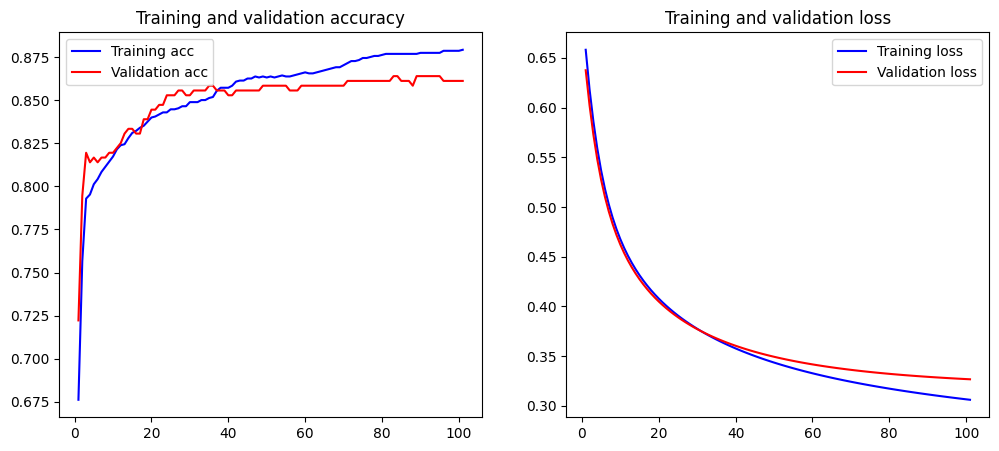

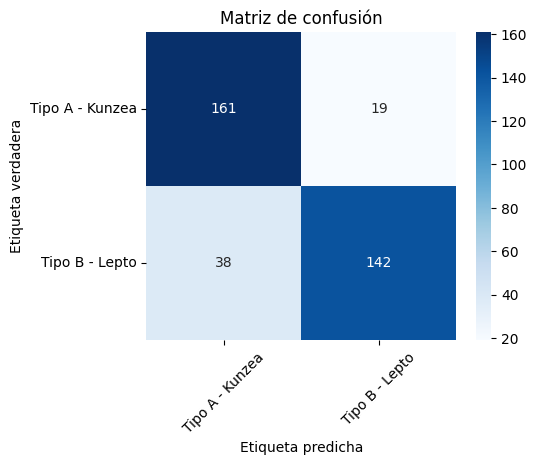

In [ ]:
model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model)

### Data Augmentation

Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 8.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.70      0.96      0.81       180
 Tipo B - Lepto       0.93      0.58      0.72       180

       accuracy                           0.77       360
      macro avg       0.81      0.77      0.76       360
   weighted avg       0.81      0.77      0.76       360


		+-----------------------+
		| Test accuracy: 0.7694 |
		+-----------------------+



Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_14 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │        10,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,005 (117.21 KB)

 Trainable params: 10,001 (39.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,004 (78.14 KB)

None


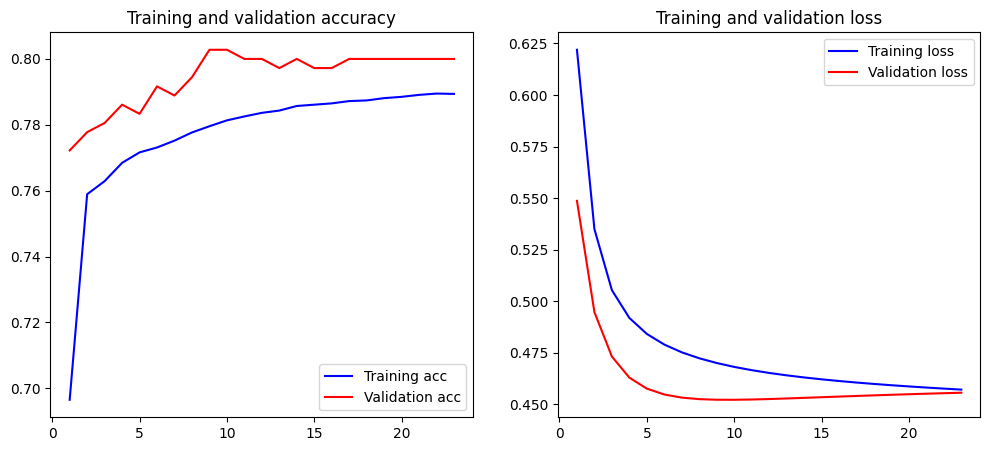

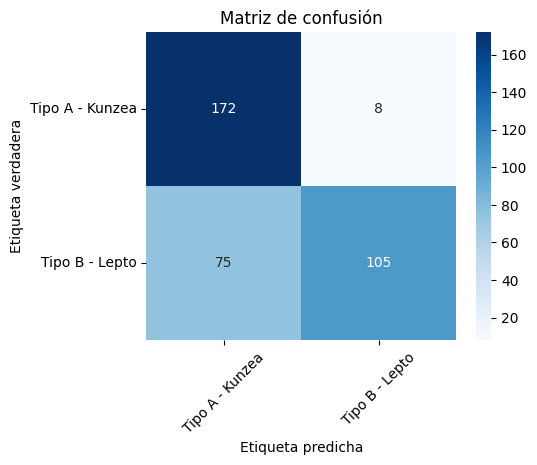

In [ ]:
# con todos

model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model, train_data=X_train_augmented, train_labels=y_train_augmented)

Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 6.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.73      0.94      0.82       180
 Tipo B - Lepto       0.92      0.64      0.76       180

       accuracy                           0.79       360
      macro avg       0.82      0.79      0.79       360
   weighted avg       0.82      0.79      0.79       360


		+-----------------------+
		| Test accuracy: 0.7944 |
		+-----------------------+



Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │        10,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,005 (117.21 KB)

 Trainable params: 10,001 (39.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,004 (78.14 KB)

None


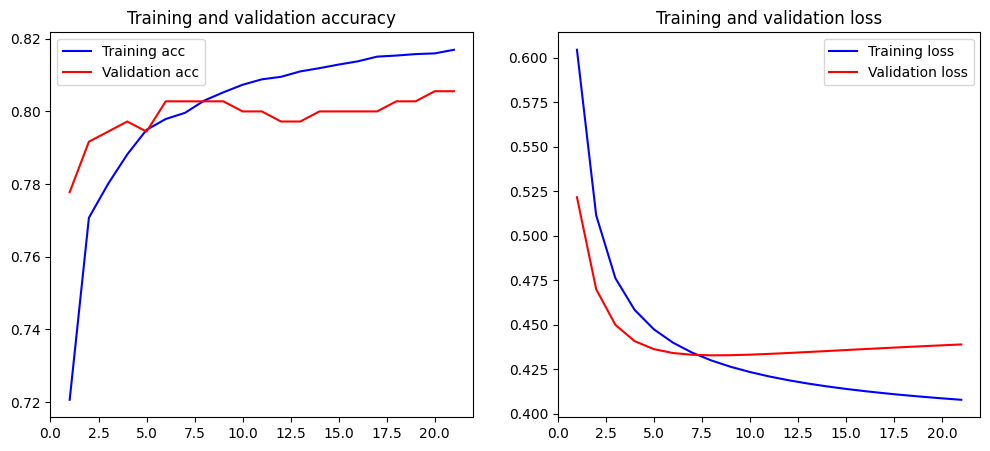

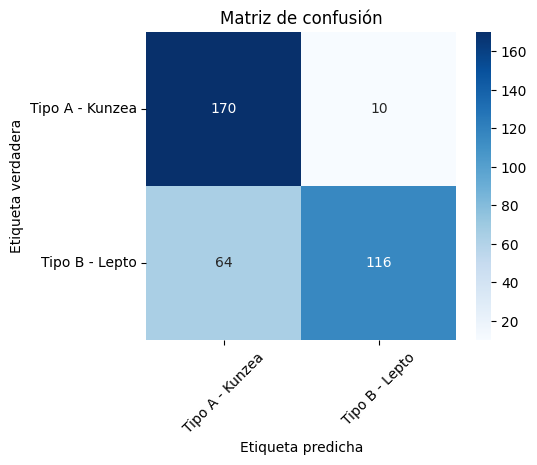

In [ ]:
# sin zoom

model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model, train_data=X_train_augmented, train_labels=y_train_augmented)

Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 8.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.73      0.94      0.82       180
 Tipo B - Lepto       0.91      0.64      0.76       180

       accuracy                           0.79       360
      macro avg       0.82      0.79      0.79       360
   weighted avg       0.82      0.79      0.79       360


		+-----------------------+
		| Test accuracy: 0.7917 |
		+-----------------------+



Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │        10,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,005 (117.21 KB)

 Trainable params: 10,001 (39.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,004 (78.14 KB)

None


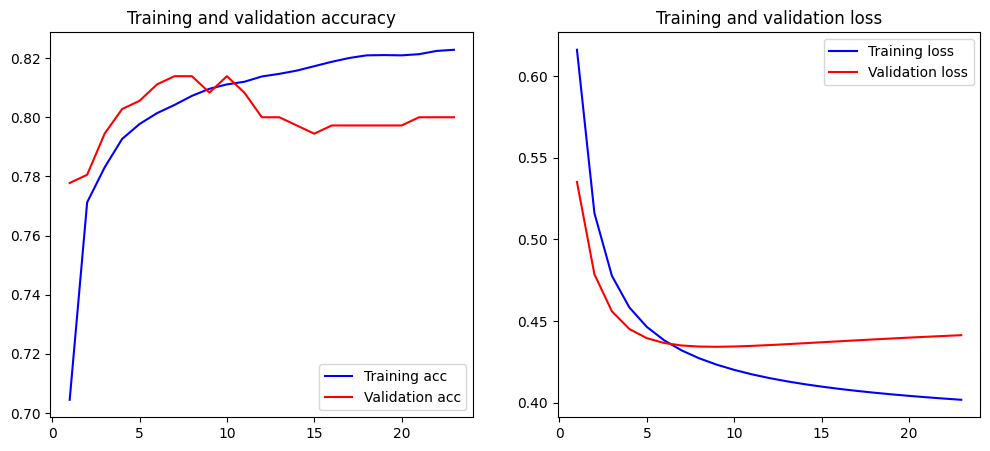

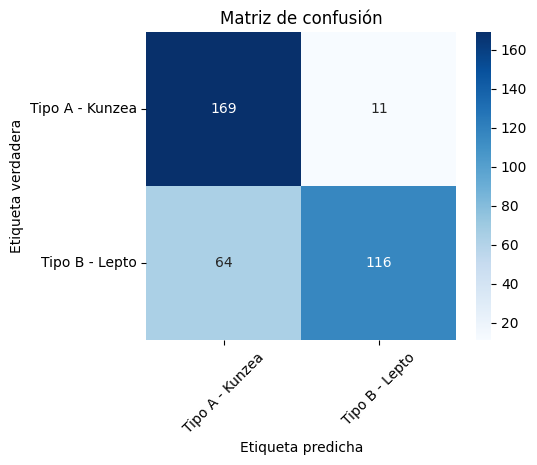

In [ ]:
# sin zoom, sin rotacion

model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model, train_data=X_train_augmented, train_labels=y_train_augmented)

## NET-2

Epoch 66: early stopping
Restoring model weights from the end of the best epoch: 51.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.88      0.95      0.91       180
 Tipo B - Lepto       0.95      0.87      0.90       180

       accuracy                           0.91       360
      macro avg       0.91      0.91      0.91       360
   weighted avg       0.91      0.91      0.91       360


		+-----------------------+
		| Test accuracy: 0.9083 |
		+-----------------------+



Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,865,349 (14.75 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,576,900 (9.83 MB)

None


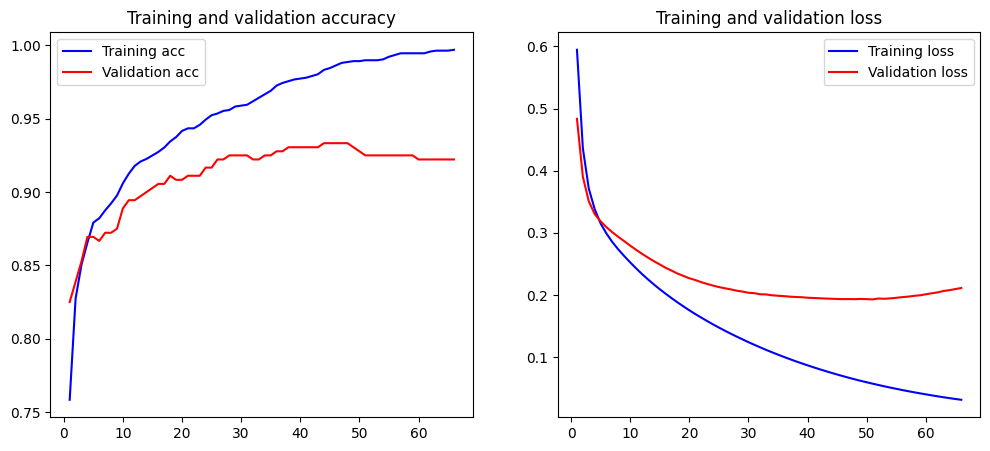

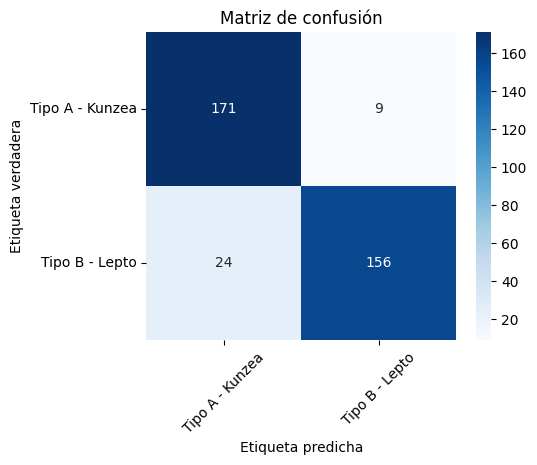

In [ ]:
model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model)

### Data Augmentation

2025-03-25 10:52:50.715642: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 403200000 exceeds 10% of free system memory.


Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 15.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.93      0.93      0.93       180
 Tipo B - Lepto       0.93      0.93      0.93       180

       accuracy                           0.93       360
      macro avg       0.93      0.93      0.93       360
   weighted avg       0.93      0.93      0.93       360


		+-----------------------+
		| Test accuracy: 0.9333 |
		+-----------------------+



Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,865,349 (14.75 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,576,900 (9.83 MB)

None


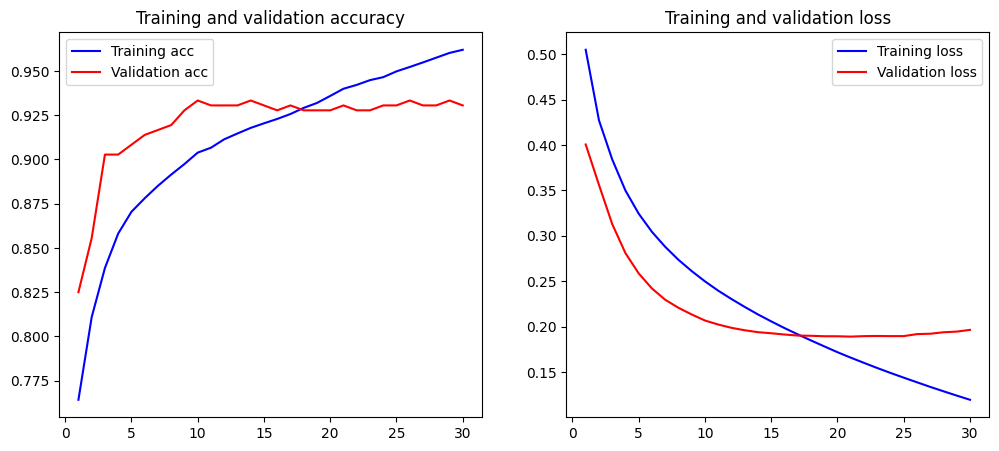

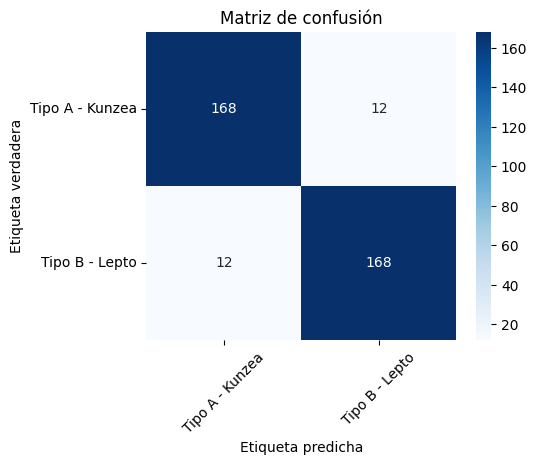

In [ ]:
# con todos

model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model, train_data=X_train_augmented, train_labels=y_train_augmented)

Epoch 37: early stopping
Restoring model weights from the end of the best epoch: 22.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.95      0.93      0.94       180
 Tipo B - Lepto       0.93      0.95      0.94       180

       accuracy                           0.94       360
      macro avg       0.94      0.94      0.94       360
   weighted avg       0.94      0.94      0.94       360


		+-----------------------+
		| Test accuracy: 0.9417 |
		+-----------------------+



Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,865,349 (14.75 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,576,900 (9.83 MB)

None


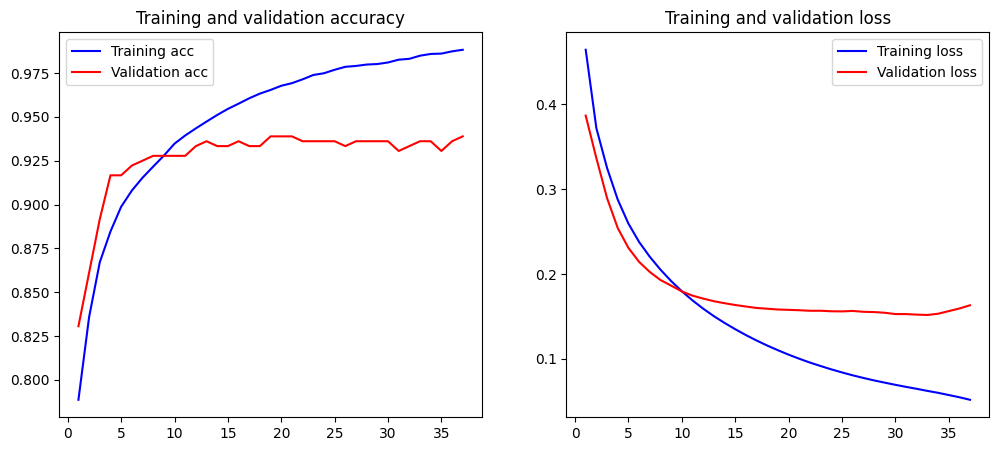

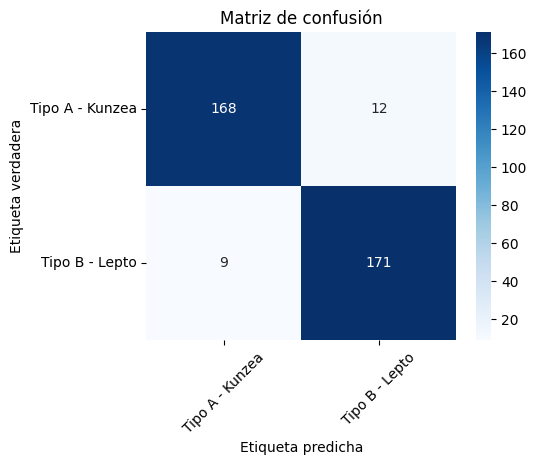

In [ ]:
# sin zoom

model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model, train_data=X_train_augmented, train_labels=y_train_augmented)

Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 14.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.95      0.91      0.93       180
 Tipo B - Lepto       0.91      0.95      0.93       180

       accuracy                           0.93       360
      macro avg       0.93      0.93      0.93       360
   weighted avg       0.93      0.93      0.93       360


		+-----------------------+
		| Test accuracy: 0.9306 |
		+-----------------------+



Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,865,349 (14.75 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,576,900 (9.83 MB)

None


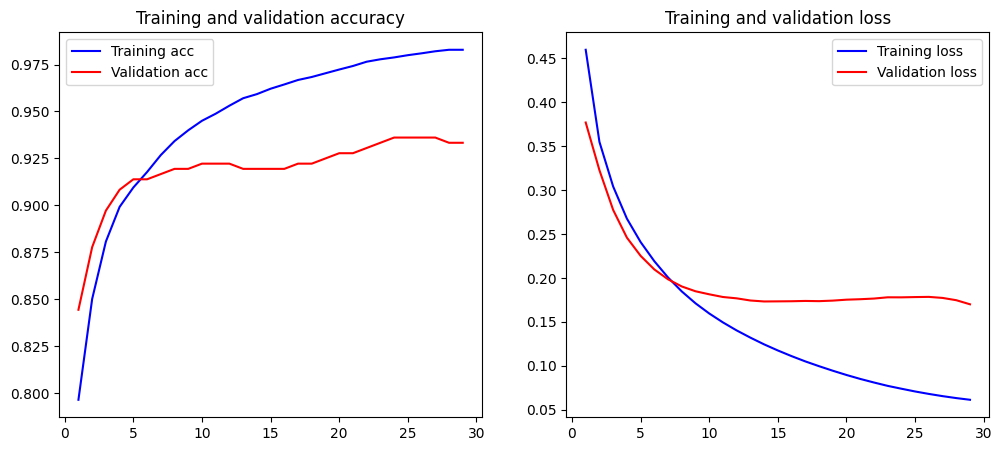

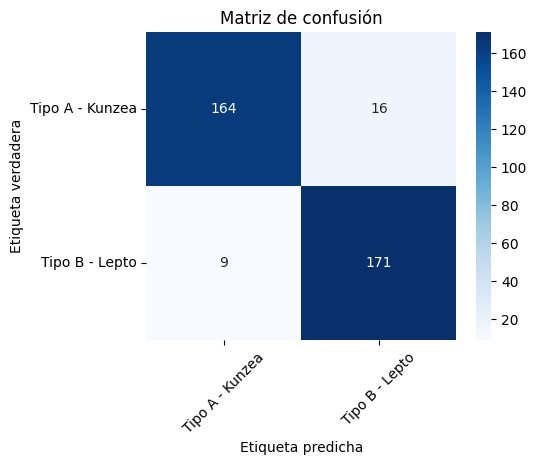

In [ ]:
# sin zoom, sin rotacion

model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model, train_data=X_train_augmented, train_labels=y_train_augmented)

## NET-3

Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 28.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.82      0.91      0.86       180
 Tipo B - Lepto       0.90      0.79      0.84       180

       accuracy                           0.85       360
      macro avg       0.86      0.85      0.85       360
   weighted avg       0.86      0.85      0.85       360


		+-----------------------+
		| Test accuracy: 0.8528 |
		+-----------------------+



Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │        33,857 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,021 (617.27 KB)

 Trainable params: 52,673 (205.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 105,348 (411.52 KB)

None


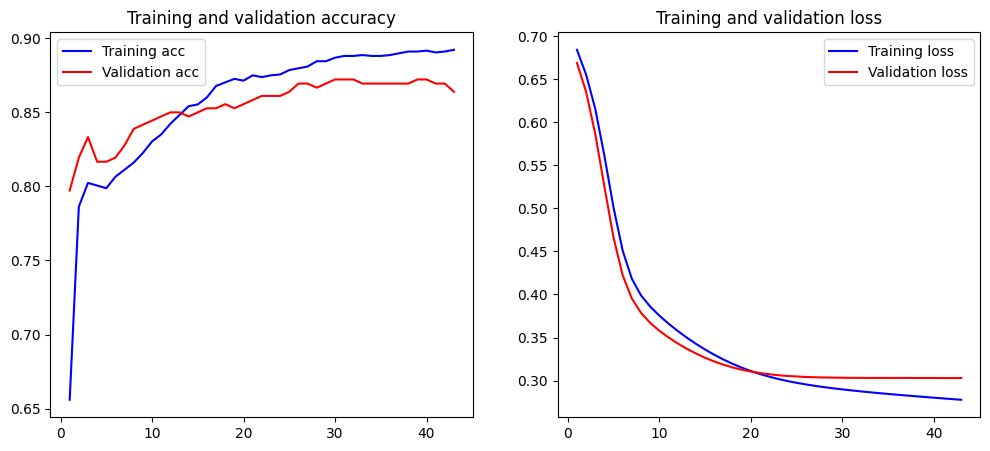

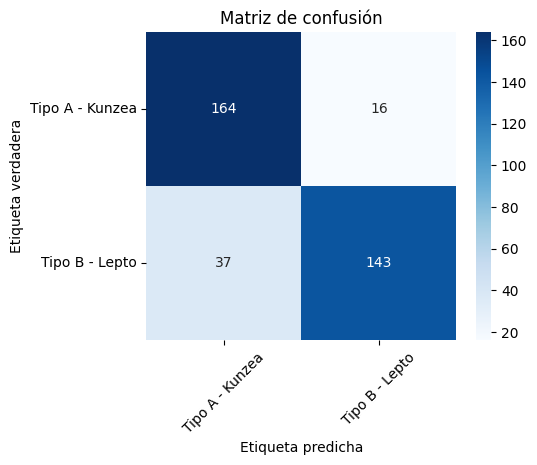

In [ ]:
model = Sequential([
    Input(shape=(100, 100, 1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model)

### Data Augmentation

Epoch 96: early stopping
Restoring model weights from the end of the best epoch: 81.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.90      0.91      0.90       180
 Tipo B - Lepto       0.91      0.90      0.90       180

       accuracy                           0.90       360
      macro avg       0.90      0.90      0.90       360
   weighted avg       0.90      0.90      0.90       360


		+-----------------------+
		| Test accuracy: 0.9028 |
		+-----------------------+



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 98, 98, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 49, 49, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 47, 47, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 33856)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │          33,857 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 158,021 (617.27 KB)

 Trainable params: 52,673 (205.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 105,348 (411.52 KB)

None


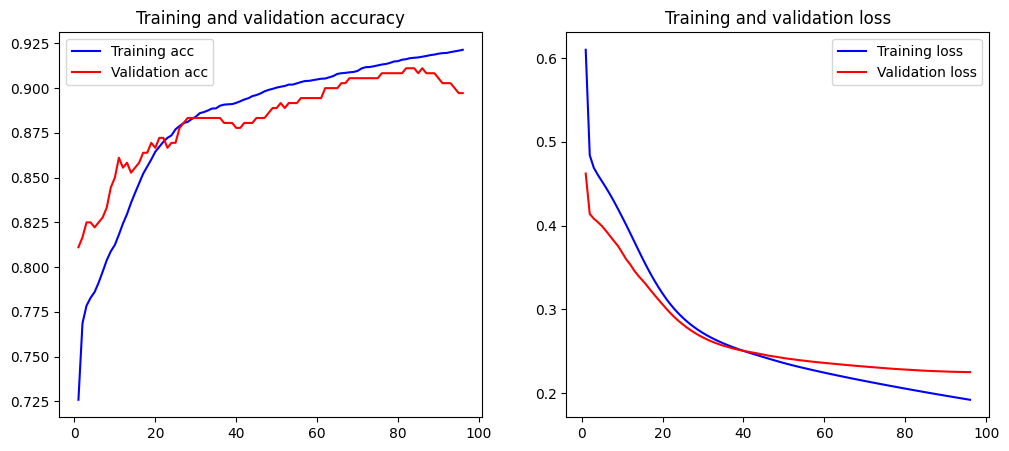

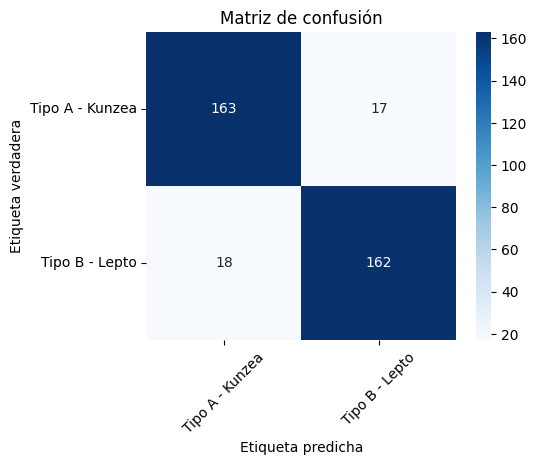

In [ ]:
# con todos

model = Sequential([
    Input(shape=(100, 100, 1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model, train_data=X_train_augmented, train_labels=y_train_augmented)

Epoch 92: early stopping
Restoring model weights from the end of the best epoch: 77.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.85      0.94      0.90       180
 Tipo B - Lepto       0.94      0.84      0.89       180

       accuracy                           0.89       360
      macro avg       0.90      0.89      0.89       360
   weighted avg       0.90      0.89      0.89       360


		+-----------------------+
		| Test accuracy: 0.8917 |
		+-----------------------+



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 98, 98, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 49, 49, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 47, 47, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 33856)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │          33,857 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 158,021 (617.27 KB)

 Trainable params: 52,673 (205.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 105,348 (411.52 KB)

None


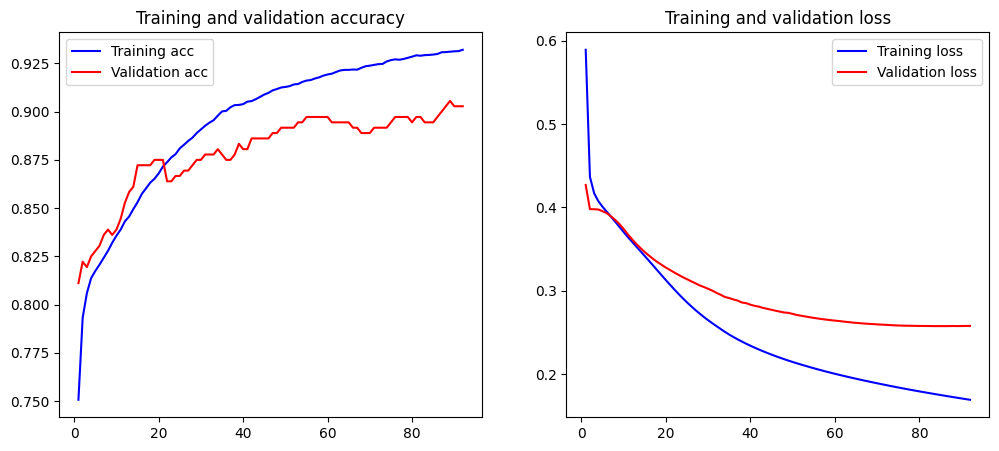

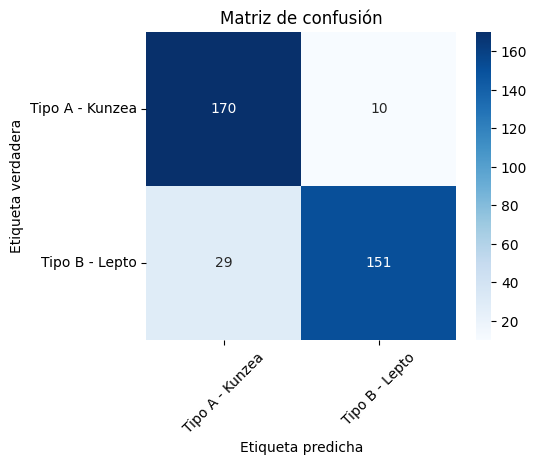

In [ ]:
# sin zoom

model = Sequential([
    Input(shape=(100, 100, 1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model, train_data=X_train_augmented, train_labels=y_train_augmented)

Epoch 89: early stopping
Restoring model weights from the end of the best epoch: 74.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.85      0.94      0.89       180
 Tipo B - Lepto       0.93      0.83      0.88       180

       accuracy                           0.89       360
      macro avg       0.89      0.89      0.89       360
   weighted avg       0.89      0.89      0.89       360


		+-----------------------+
		| Test accuracy: 0.8861 |
		+-----------------------+



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 98, 98, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 49, 49, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 47, 47, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 33856)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │          33,857 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 158,021 (617.27 KB)

 Trainable params: 52,673 (205.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 105,348 (411.52 KB)

None


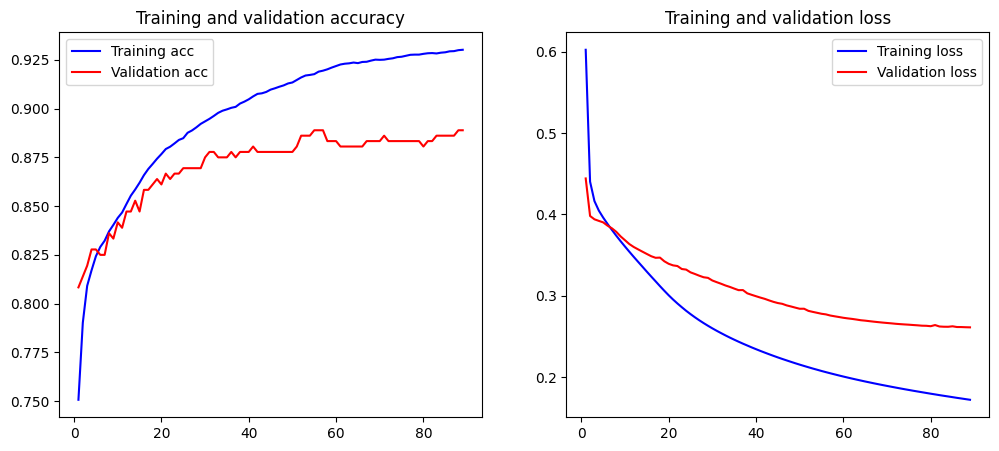

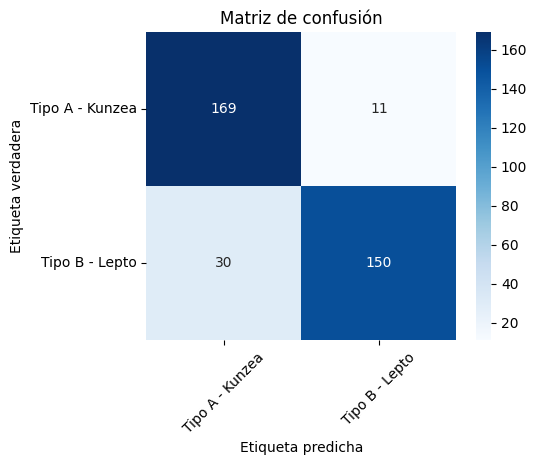

In [ ]:
# sin zoom, sin rotacion

model = Sequential([
    Input(shape=(100, 100, 1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model, train_data=X_train_augmented, train_labels=y_train_augmented)

## NET-4

Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 28.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.90      0.96      0.93       180
 Tipo B - Lepto       0.95      0.89      0.92       180

       accuracy                           0.93       360
      macro avg       0.93      0.93      0.92       360
   weighted avg       0.93      0.93      0.92       360


		+-----------------------+
		| Test accuracy: 0.925 |
		+-----------------------+



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)                   │ (None, 98, 98, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 49, 49, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 47, 47, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 21, 21, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │           4,097 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,175,813 (4.49 MB)

 Trainable params: 391,937 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 783,876 (2.99 MB)

None


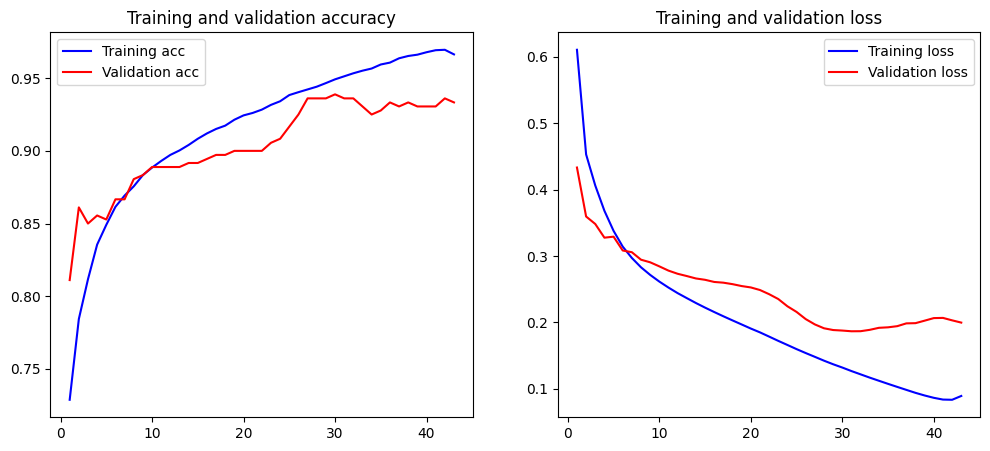

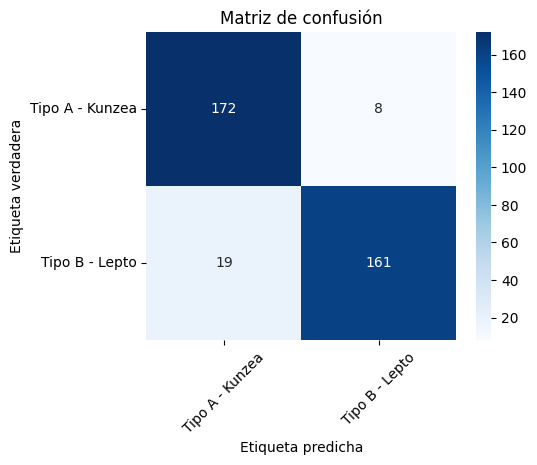

In [ ]:
model = Sequential([
    Input(shape=(100, 100, 1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model, train_data=X_train_augmented, train_labels=y_train_augmented)

## NET-5

Epoch 36: early stopping
Restoring model weights from the end of the best epoch: 21.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.94      0.94      0.94       180
 Tipo B - Lepto       0.94      0.94      0.94       180

       accuracy                           0.94       360
      macro avg       0.94      0.94      0.94       360
   weighted avg       0.94      0.94      0.94       360


		+-----------------------+
		| Test accuracy: 0.9417 |
		+-----------------------+



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 98, 98, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 49, 49, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 47, 47, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 33856)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │       4,333,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,082,501 (49.91 MB)

 Trainable params: 4,360,833 (16.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,721,668 (33.27 MB)

None


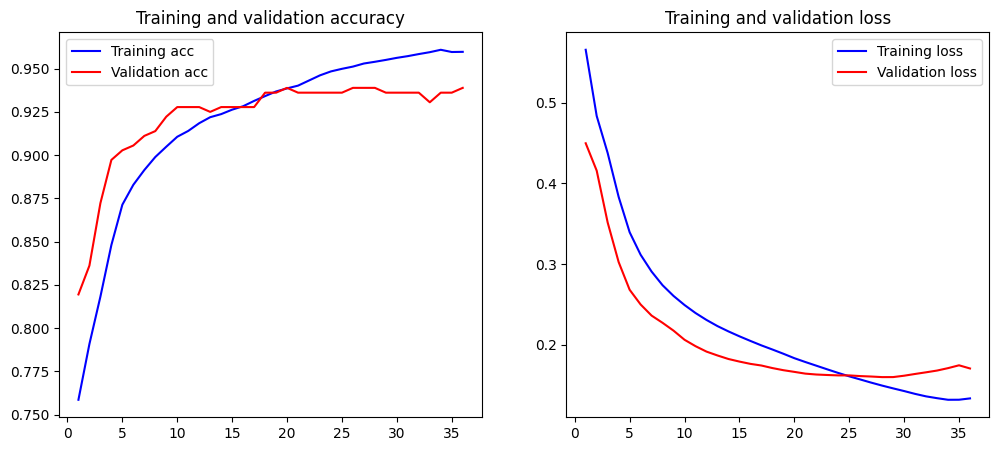

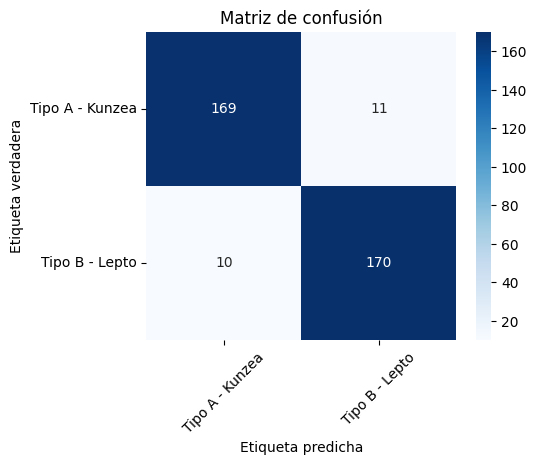

In [22]:
model = Sequential([
    Input(shape=(100, 100, 1)),

    Conv2D(32, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model, train_data=X_train_augmented, train_labels=y_train_augmented)

# Visualización

In [ ]:
model = tf.keras.models.load_model('./models/model_3.keras')
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │        33,857 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,021 (617.27 KB)

 Trainable params: 52,673 (205.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 105,348 (411.52 KB)

In [ ]:
conv_layer_indices = [index for index, layer in enumerate(model.layers) if isinstance(layer, Conv2D)]

## Pesos

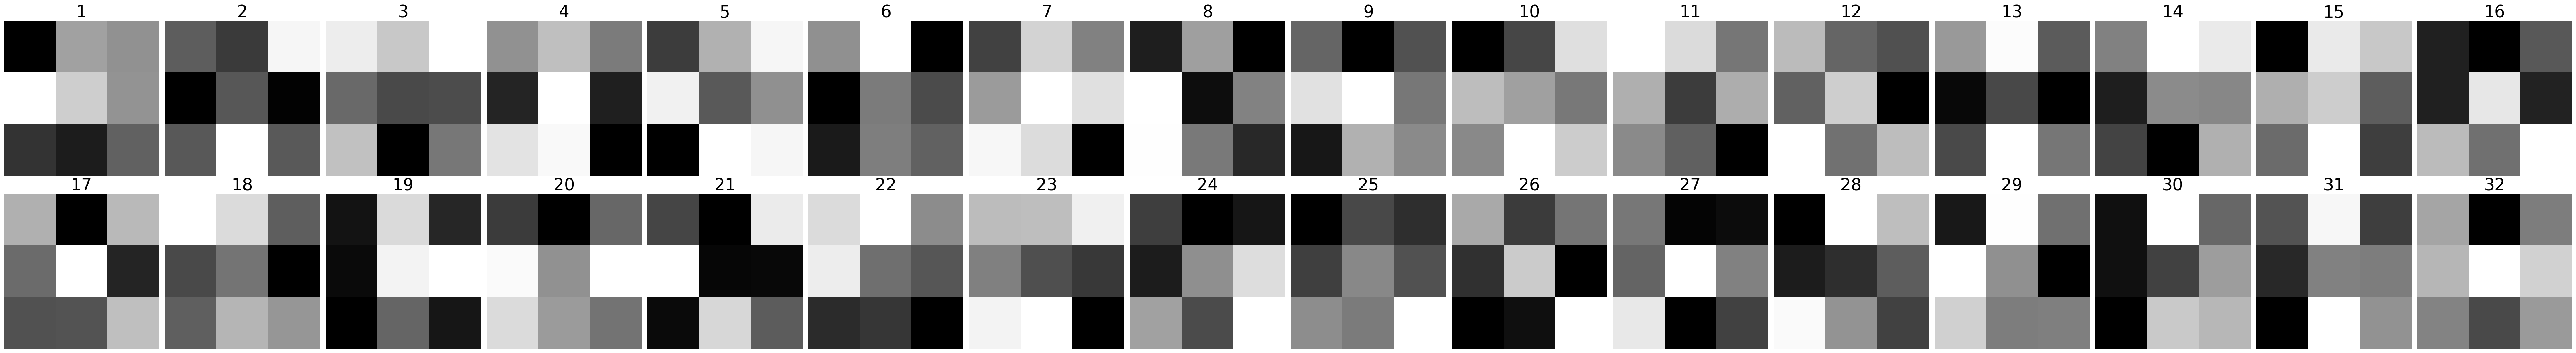

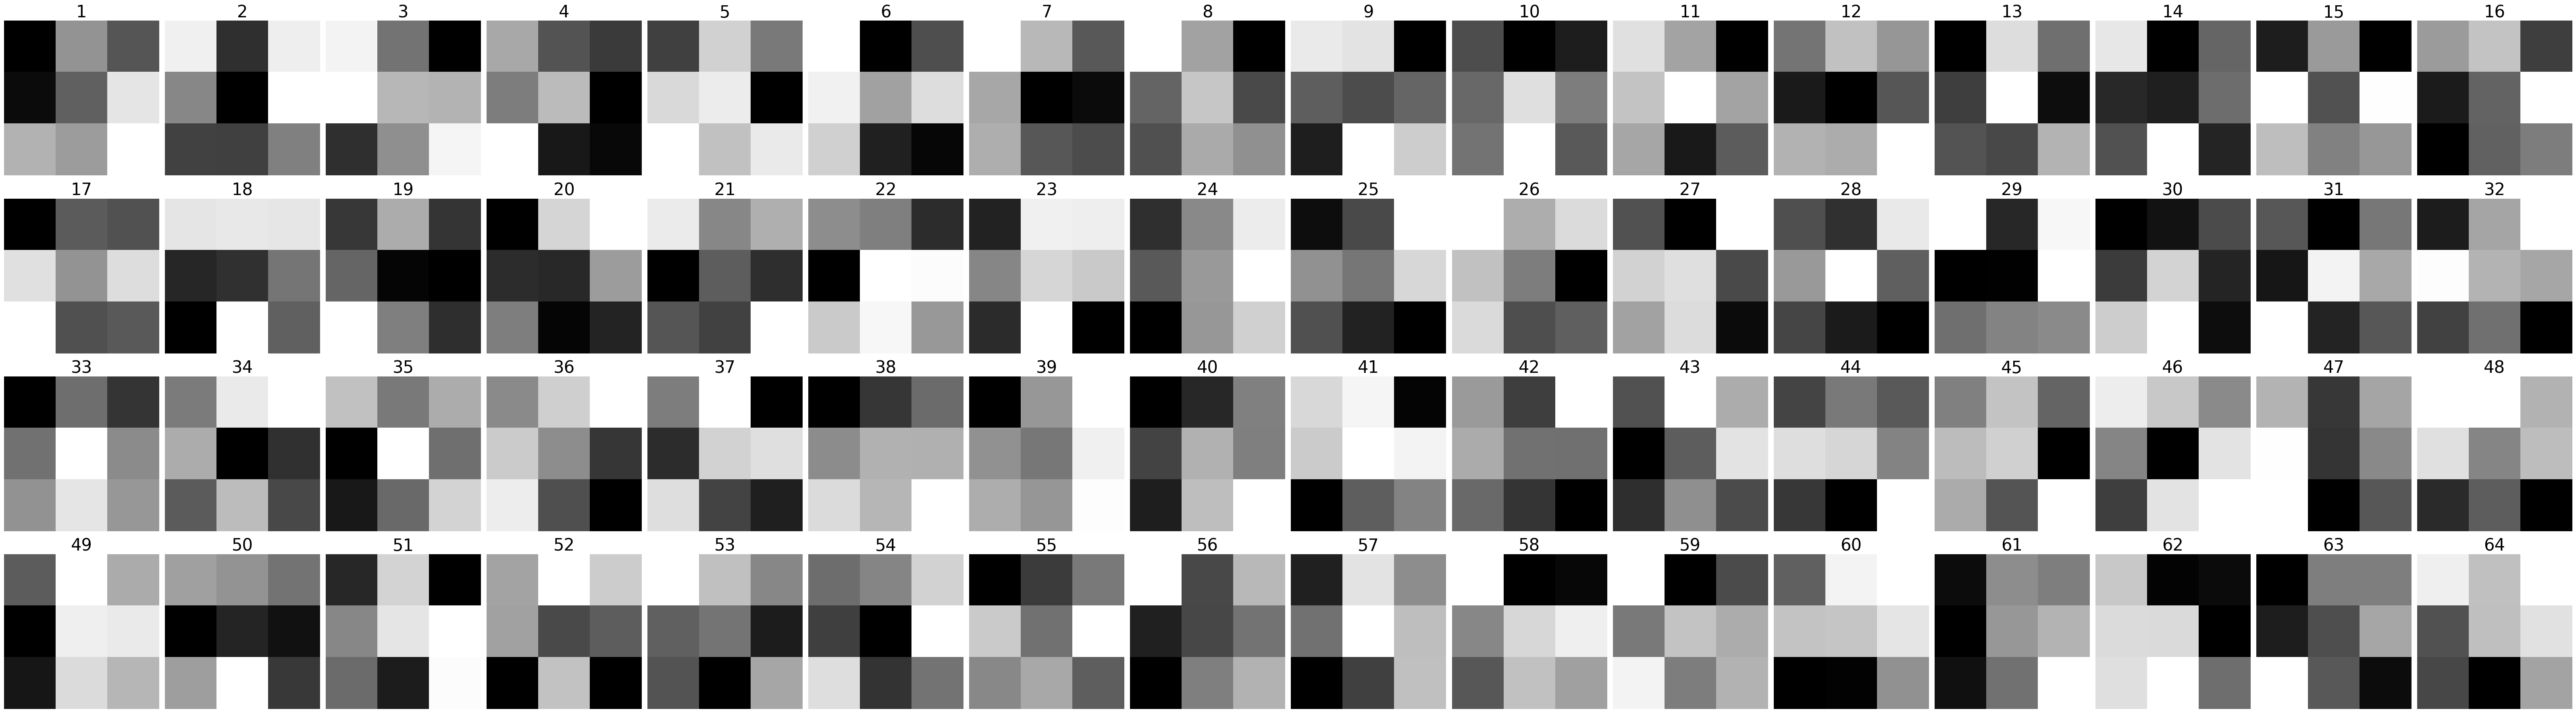

In [ ]:
for layer_index in conv_layer_indices:
    # pesos
    layer = model.layers[layer_index]
    filters, biases = layer.get_weights()

    # Normalizar
    f_min, f_max = filters.min(), filters.max()
    filters = (filters - f_min) / (f_max - f_min)


    n_filters = filters.shape[3]
    grid_cols = 16
    grid_rows = int(np.ceil(n_filters / grid_cols))

    # grafica
    plt.figure(figsize=(4*grid_cols, 4.5*grid_rows))

    for i in range(n_filters):
        f = filters[:, :, 0, i]

        plt.subplot(grid_rows, grid_cols, i+1)
        plt.imshow(f, cmap='gray')
        plt.title(f'{i+1}', fontsize=30)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

## Mapas

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


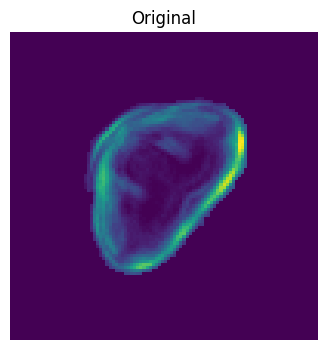

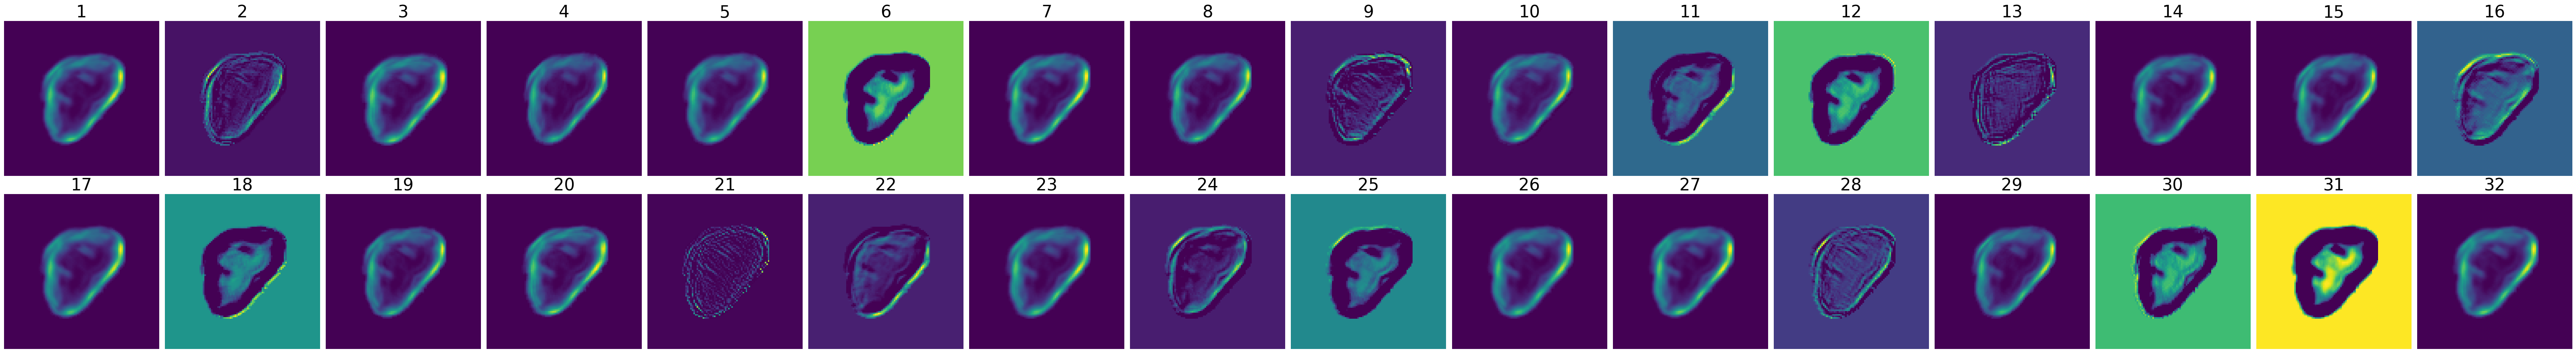

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


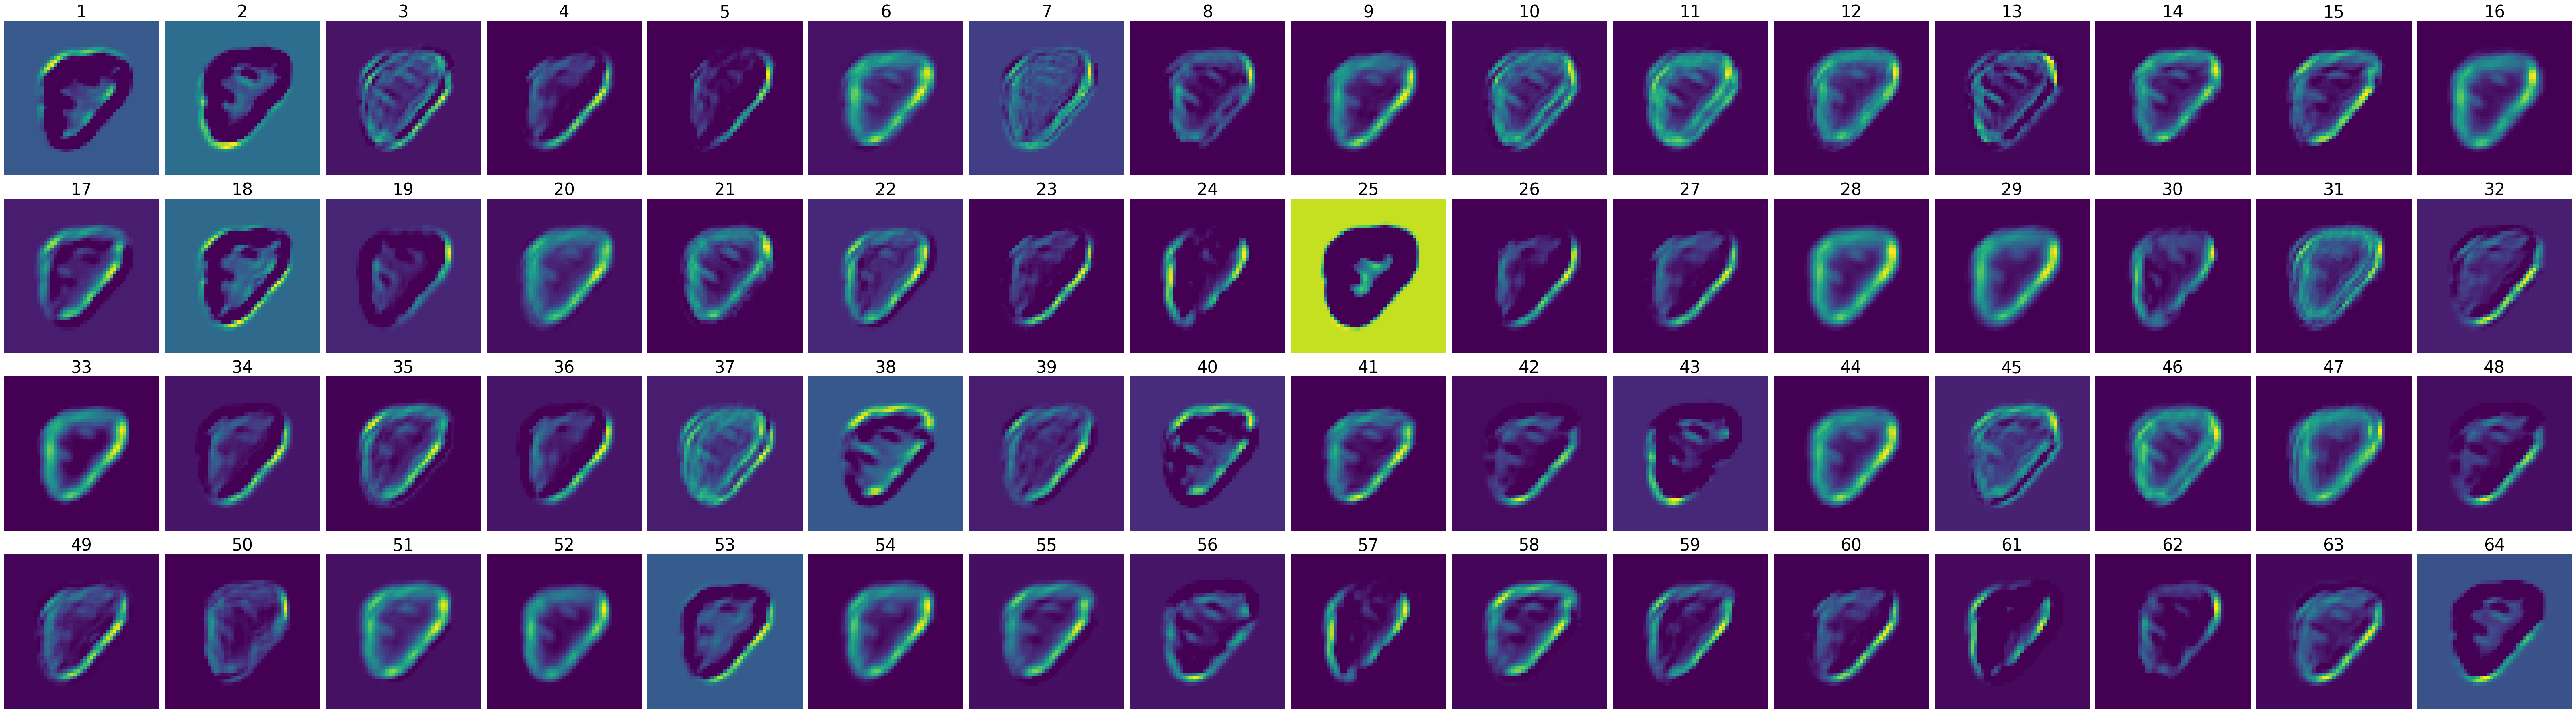

In [18]:
input_image = np.expand_dims(X_train[15], axis=0)

plt.figure(figsize=(4, 4))
plt.imshow(input_image.squeeze()) #, cmap='gray')
plt.title("Original")
plt.axis("off")



for layer_index in conv_layer_indices:
    # Crear modelo que extrae mapas de características de la capa especificada
    feature_map_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=model.layers[layer_index].output
    )

    feature_maps = feature_map_model.predict(input_image)

    n_maps = feature_maps.shape[3]
    grid_cols = 16
    grid_rows = int(np.ceil(n_maps / grid_cols))

    # grafica
    plt.figure(figsize=(4*grid_cols, 4.5*grid_rows))

    for i in range(n_maps):
        plt.subplot(grid_rows, grid_cols, i+1)
        plt.imshow(feature_maps[0, :, :, i]) #, cmap='gray')
        plt.title(f'{i+1}', fontsize=30)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# Grafica conjunta

In [20]:
import joblib

history_1 = joblib.load('models/history_1.joblib')
history_2 = joblib.load('models/history_2.joblib')
history_3 = joblib.load('models/history_3.joblib')
history_4 = joblib.load('models/history_4.joblib')
history_5 = joblib.load('models/history_5.joblib')

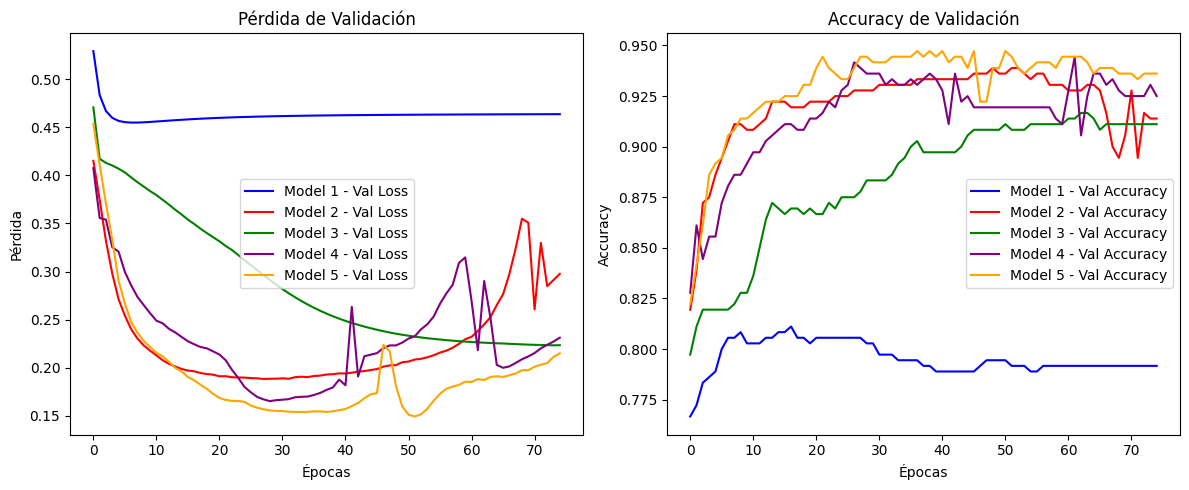

In [21]:
import matplotlib.pyplot as plt

# Lista de historiales de entrenamiento
histories = [history_1, history_2, history_3, history_4, history_5]

# Colores para cada modelo
colors = ['blue', 'red', 'green', 'purple', 'orange']

# Crear figura
plt.figure(figsize=(12, 5))

# Subplot para la pérdida de validación
plt.subplot(1, 2, 1)
for i, history in enumerate(histories):
    plt.plot(history.history['val_loss'], color=colors[i], label=f'Model {i+1} - Val Loss')
plt.title('Pérdida de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

# Subplot para accuracy de validación
plt.subplot(1, 2, 2)
for i, history in enumerate(histories):
    plt.plot(history.history['val_acc'], color=colors[i], label=f'Model {i+1} - Val Accuracy')
plt.title('Accuracy de Validación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Ajustar diseño y mostrar gráfica
plt.tight_layout()
plt.show()

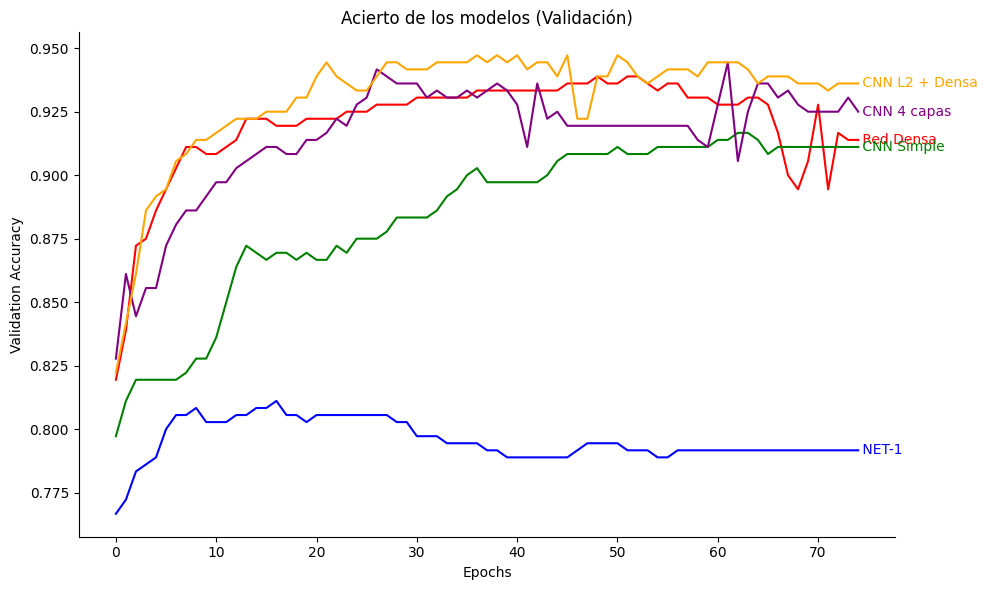

In [23]:
import matplotlib.pyplot as plt

# Lista de nombres de modelos
model_names = ['NET-1', 'Red Densa', 'CNN Simple', 'CNN 4 capas', 'CNN L2 + Densa']

# Colores para cada modelo
colors = ['blue', 'red', 'green', 'purple', 'orange']

# Crear figura
plt.figure(figsize=(10, 6))

# Eliminar bordes superior e izquierdo
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Plotear curvas de accuracy de validación
for i, history in enumerate(histories):
    val_accuracy = history.history['val_acc']
    plt.plot(val_accuracy, color=colors[i])

    # Añadir etiqueta al final de cada curva
    plt.text(len(val_accuracy)-1, val_accuracy[-1], f' {model_names[i]}',
             verticalalignment='center',
             color=colors[i])

plt.title('Acierto de los modelos (Validación)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')

# Eliminar leyenda
plt.gca().get_legend().remove() if plt.gca().get_legend() else None

plt.tight_layout()
plt.show()